# 4. Preprocessing

### Connecting Google Drive

In [1]:
# connect GoogleColab with my GoogleDrive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# store prefix path to access all files on my google drive
prefix_path = '/content/drive/My Drive/KeepCoding/DeepLearning/Practica/'

Mounted at /content/drive


### Reading data file

In [2]:
# import libraries
import pandas as pd
import os
import pickle

# load data
df_train = pd.read_pickle(prefix_path + 'df_train.pkl')
df_val   = pd.read_pickle(prefix_path + 'df_val.pkl')
df_test  = pd.read_pickle(prefix_path + 'df_test.pkl')

print(f"Train: {len(df_train)} rows")
print(f"Val:   {len(df_val)} rows")
print(f"Test:  {len(df_test)} rows")
print(f"\nColumns: {list(df_train.columns)}")

Train: 1077 rows
Val:   191 rows
Test:  224 rows

Columns: ['id', 'name', 'shortDescription', 'categories', 'tier', 'locationLon', 'locationLat', 'tags', 'xps', 'Visits', 'Likes', 'Dislikes', 'Bookmarks', 'main_image_path', 'categories_count', 'tags_count', 'C', 'S', 'V', 'E', 'engagement_label', 'Arquitectura', 'Ciencia', 'Cine', 'Cultura', 'Escultura', 'Gastronomía', 'Historia', 'Misterio', 'Naturaleza', 'Ocio', 'Patrimonio', 'Pintura']


## a. Normalize 'tier', 'xps', 'latitude', 'longitude'

In [3]:
import sys
sys.path.append('/content/drive/My Drive/KeepCoding/DeepLearning/Practica/')

In [4]:
from poi_utils import normalize_features, normalize_coordinates

# Step 1: normalize tier and xps (fixed ranges, no leakage)
df_train = normalize_features(df_train)
df_val   = normalize_features(df_val)
df_test  = normalize_features(df_test)

# Step 2: compute coordinate stats from training set only
lon_mean, lon_std = df_train['locationLon'].mean(), df_train['locationLon'].std()
lat_mean, lat_std = df_train['locationLat'].mean(), df_train['locationLat'].std()

# Step 3: normalize coordinates for all splits
df_train = normalize_coordinates(df_train, lon_mean, lon_std, lat_mean, lat_std)
df_val   = normalize_coordinates(df_val,   lon_mean, lon_std, lat_mean, lat_std)
df_test  = normalize_coordinates(df_test,  lon_mean, lon_std, lat_mean, lat_std)

# Verify
print(df_train[['tier_norm', 'xps_norm', 'locationLon_norm', 'locationLat_norm']].describe())

         tier_norm     xps_norm  locationLon_norm  locationLat_norm
count  1077.000000  1077.000000      1.077000e+03      1.077000e+03
mean      0.185082     0.743593     -4.123391e-18      1.220524e-16
std       0.211201     0.223764      1.000000e+00      1.000000e+00
min       0.000000     0.000000     -5.612021e+00     -1.127377e+01
25%       0.000000     0.600000     -8.852809e-02      8.038599e-02
50%       0.000000     0.700000     -8.730467e-02      8.144754e-02
75%       0.333333     1.000000     -8.639548e-02      8.590516e-02
max       1.000000     1.000000      7.482908e+00      2.859232e+00


## c. Latitude & Longitude: geographic embedding

For Latitude and Longitude,  in addition to normalizing the values for fine granularity, I will also be using KMeans for finding natural clusters, which will allow me to address the issues related to coarser granularity for data outside of Madrid.

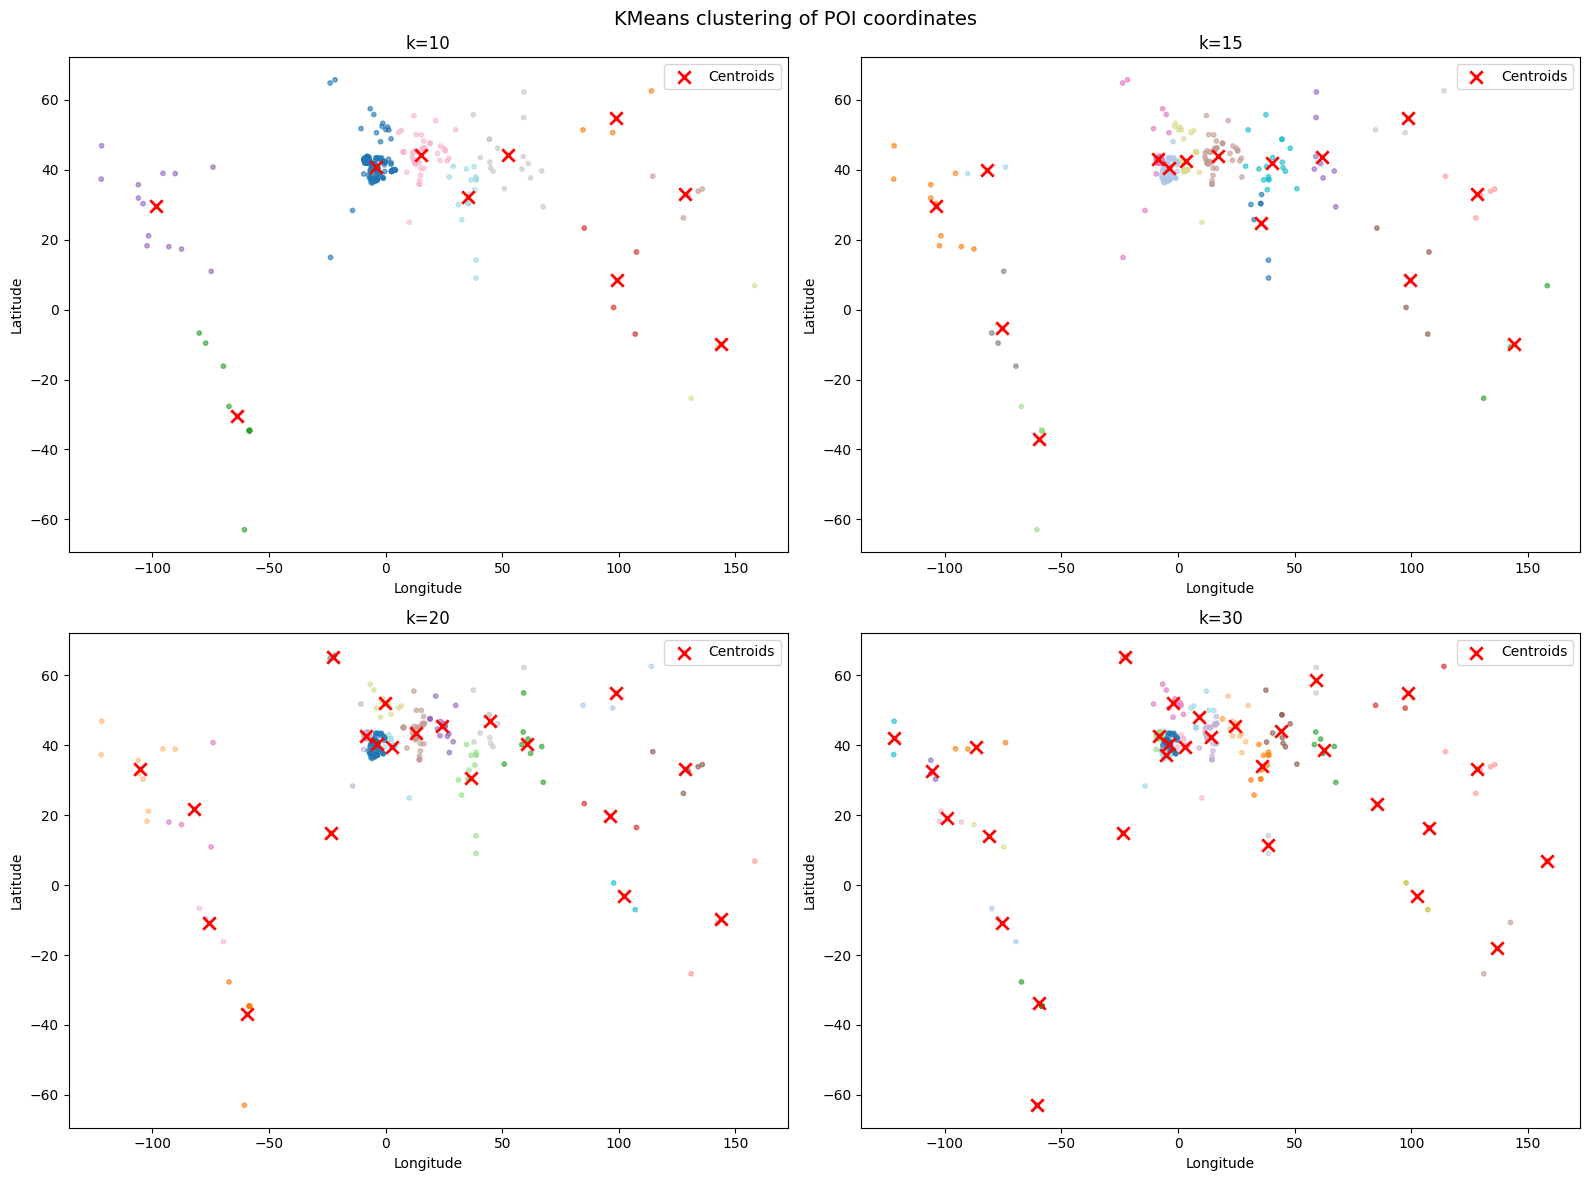

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

##################################
# Fit KMeans on training set only
##################################
coords_train = df_train[['locationLon', 'locationLat']].values

# Try different values of k
k_values = [10, 15, 20, 30]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, k in zip(axes, k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coords_train)

    # Assign clusters to training set
    train_clusters = kmeans.predict(coords_train)

    # Plot
    ax.scatter(df_train['locationLon'], df_train['locationLat'],
               c=train_clusters, cmap='tab20', s=10, alpha=0.6)
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
               c='red', s=80, marker='x', linewidths=2, label='Centroids')
    ax.set_title(f'k={k}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend()

plt.suptitle('KMeans clustering of POI coordinates', fontsize=14)
plt.tight_layout()
plt.show()

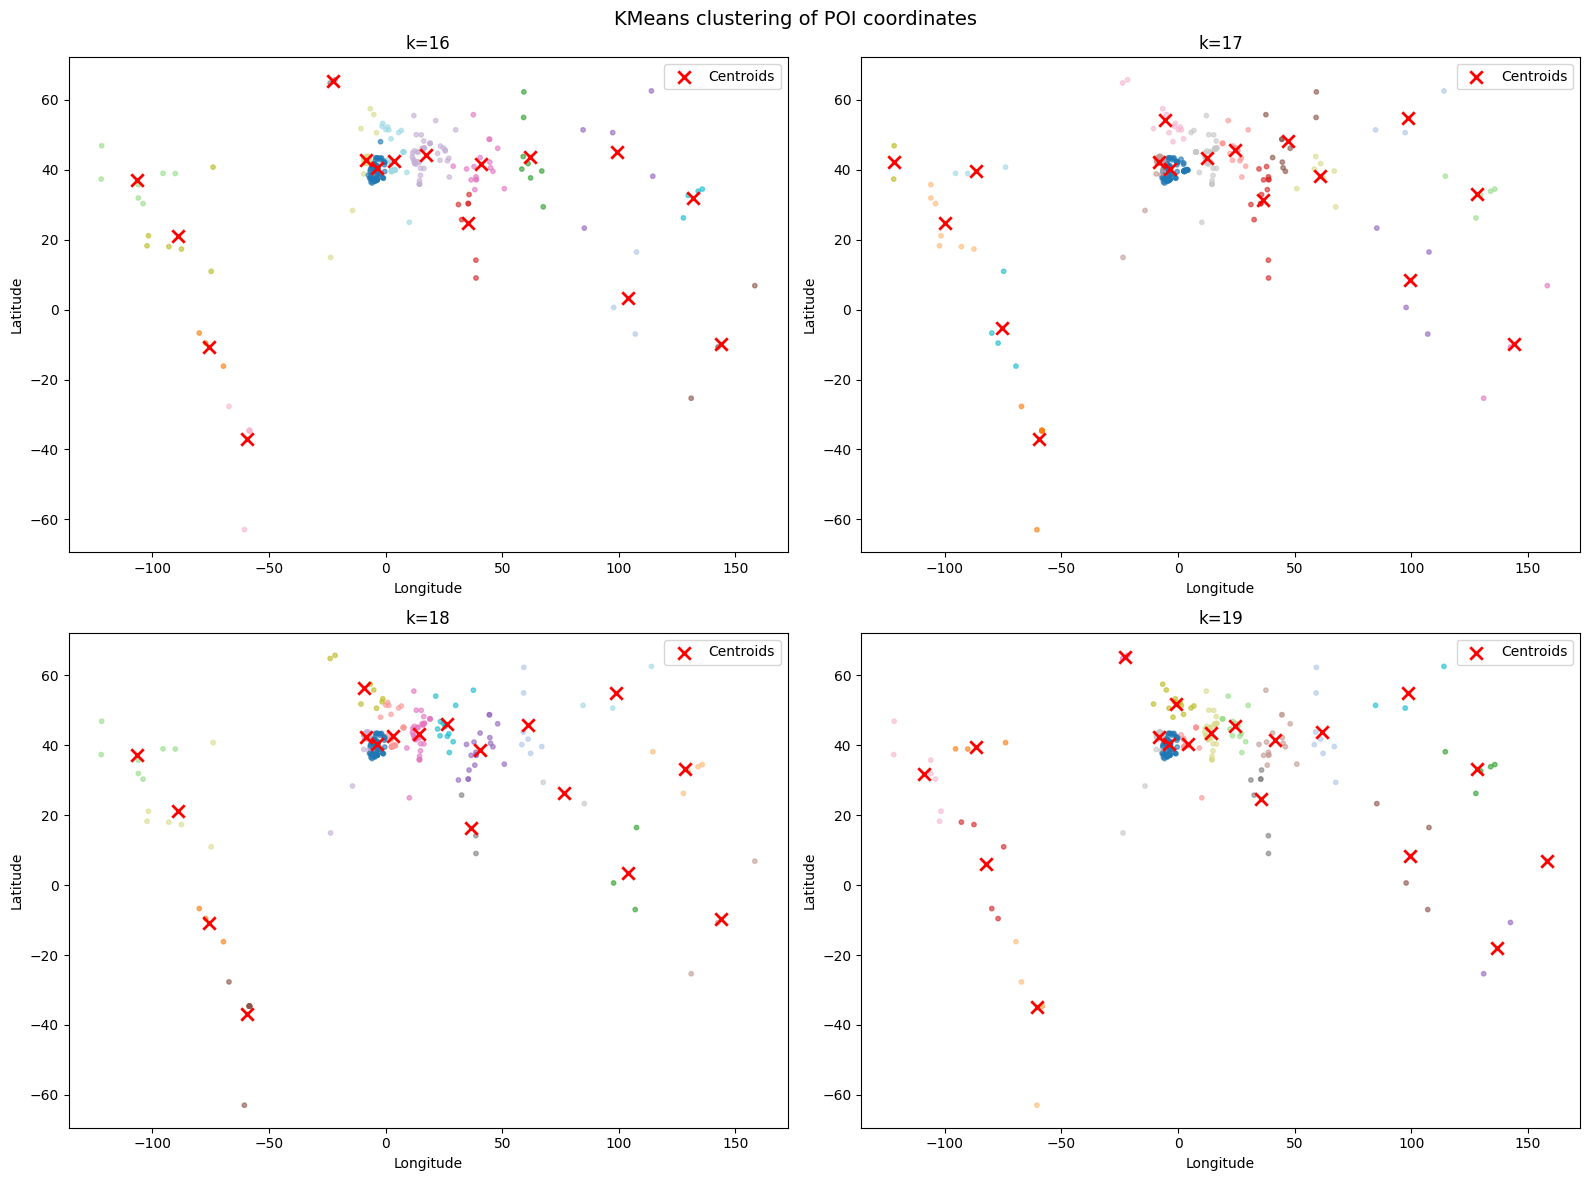

In [6]:
# Try different values of k
k_values = [16, 17, 18, 19]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, k in zip(axes, k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coords_train)

    # Assign clusters to training set
    train_clusters = kmeans.predict(coords_train)

    # Plot
    ax.scatter(df_train['locationLon'], df_train['locationLat'],
               c=train_clusters, cmap='tab20', s=10, alpha=0.6)
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
               c='red', s=80, marker='x', linewidths=2, label='Centroids')
    ax.set_title(f'k={k}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend()

plt.suptitle('KMeans clustering of POI coordinates', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Find clusters using KMeans (for coarse granularization)
from poi_utils import fit_kmeans, assign_clusters

# Fit on training set only
kmeans = fit_kmeans(df_train, k=17)

# Assign clusters to all splits
df_train = assign_clusters(df_train, kmeans)
df_val   = assign_clusters(df_val,   kmeans)
df_test  = assign_clusters(df_test,  kmeans)

# Verify
print(df_train['geo_cluster'].value_counts().sort_index())

geo_cluster
0     819
1       3
2       9
3       7
4       5
5      14
6      15
7       4
8      10
9     120
10      3
11     13
12     39
13      2
14      7
15      4
16      3
Name: count, dtype: int64


In [16]:
from poi_utils import fit_kmeans, compute_centroid_distances

# Fit on training set only
kmeans = fit_kmeans(df_train, k=10)

# Compute raw distances for training set first to get normalization stats
df_train = compute_centroid_distances(df_train, kmeans)

# Compute normalization stats from training set only
dist_cols = [f'dist_centroid_{i}' for i in range(10)]
dist_mean = df_train[dist_cols].mean().values
dist_std  = df_train[dist_cols].std().values

# Recompute with normalization for all splits
df_train = compute_centroid_distances(df_train, kmeans, dist_mean, dist_std)
df_val   = compute_centroid_distances(df_val,   kmeans, dist_mean, dist_std)
df_test  = compute_centroid_distances(df_test,  kmeans, dist_mean, dist_std)

# Verify
print(df_train[[f'dist_centroid_{i}' for i in range(10)]].describe())

       dist_centroid_0  dist_centroid_1  dist_centroid_2  dist_centroid_3  \
count     1.077000e+03     1.077000e+03     1.077000e+03     1.077000e+03   
mean      4.948069e-18    -4.708913e-16    -2.729685e-16     1.599876e-16   
std       1.000000e+00     1.000000e+00     1.000000e+00     1.000000e+00   
min      -3.545886e-01    -5.365942e+00    -5.438335e+00    -5.729246e+00   
25%      -3.320755e-01     3.908866e-02    -1.255321e-01     4.931596e-02   
50%      -3.313502e-01     4.021091e-02    -1.245002e-01     5.055162e-02   
75%      -1.802905e-01     4.159855e-02    -1.230415e-01     5.206392e-02   
max       7.176590e+00     6.482487e+00     7.838167e+00     6.778967e+00   

       dist_centroid_4  dist_centroid_5  dist_centroid_6  dist_centroid_7  \
count     1.077000e+03     1.077000e+03     1.077000e+03     1.077000e+03   
mean      1.929747e-16    -9.846658e-16    -4.123391e-17    -9.153928e-17   
std       1.000000e+00     1.000000e+00     1.000000e+00     1.000000e+00  

In [17]:
# Save all this new work to pickle
df_train.to_pickle(prefix_path + 'df_train.pkl')
df_val.to_pickle(prefix_path + 'df_val.pkl')
df_test.to_pickle(prefix_path + 'df_test.pkl')

# Also save the kmeans model and normalization stats for later use
import pickle

with open(prefix_path + 'kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open(prefix_path + 'norm_stats.pkl', 'wb') as f:
    pickle.dump({
        'lon_mean': lon_mean, 'lon_std': lon_std,
        'lat_mean': lat_mean, 'lat_std': lat_std,
        'dist_mean': dist_mean, 'dist_std': dist_std
    }, f)

print("All files saved successfully.")

All files saved successfully.


## Create the POIDataset instances and the DataLoader objects

In [18]:
from poi_utils import POIDataset, transform_train, transform_val_test
from torch.utils.data import DataLoader

# Create datasets
train_dataset = POIDataset(df_train, prefix_path, transform=transform_train)
val_dataset   = POIDataset(df_val,   prefix_path, transform=transform_val_test)
test_dataset  = POIDataset(df_test,  prefix_path, transform=transform_val_test)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Test a batch
images, metadata, labels, scores = next(iter(train_loader))
print(f"Images shape:   {images.shape}")
print(f"Metadata shape: {metadata.shape}")
print(f"Labels shape:   {labels.shape}")
print(f"Scores shape:   {scores.shape}")

Images shape:   torch.Size([32, 3, 224, 224])
Metadata shape: torch.Size([32, 28])
Labels shape:   torch.Size([32])
Scores shape:   torch.Size([32])
